# Imports

In [1]:
import os

cwd = os.getcwd()
os.chdir("/home/yoshi0428/PycharmProjects/osu-predict")

In [2]:
import json
import pickle
from collections import Counter
from datetime import datetime

import numpy as np
import optuna
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

from beatmap_classifier.classifier.augment_faster import (
    augment_dataset,
    extract_movement_features_from_X,
)
from beatmap_classifier.classifier.cnn_model import CNNModel
from beatmap_classifier.classifier.utils_training import (
    get_additional_features,
    get_data,
    load_pytorch_models,
    pad_sequences_pt,
    plot_training_history,
    train_and_evaluate,
)

# Model Testing

Go run test_model.py

# Initializing some Data

In [3]:
TOURNAMENT_MODS = {
    "nm1": "NM",
    "nm2": "NM",
    "nm3": "NM",
    "nm4": "NM",
    "nm5": "NM",
    "nm6": "NM",
    "hd1": "HD",
    "hd2": "HD",
    "hd3": "HD",
    "hr1": "HR",
    "hr2": "HR",
    "hr3": "HR",
    "dt1": "DT",
    "dt2_and_dt3": "DT",
    "dt4": "DT",
    "tiebreaker": "NM",
}

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

db_path = "./beatmap_classifier/beatmaps.db"

X, y, beatmap_ids = get_data(db_path)
raw_additional_features, normalized_additional_features = get_additional_features(
    db_path, y, beatmap_ids
)

Max Vector Length: 500.0
Max Time Diff: 86087.0
Tournament-labeled beatmaps: 3922
Max Vector Count: 6309
Original beatmaps: 3922


In [5]:
# Get the mod associated with each tournament label
mods_flattened = [
    TOURNAMENT_MODS[label] if TOURNAMENT_MODS[label] else "NM" for label in y
]

raw_additional_features_array = np.array(
    [
        raw_additional_features[(beatmap_id, mod)]
        for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
    ]
)

normalized_additional_features_array = np.array(
    [
        normalized_additional_features[(beatmap_id, mod)]
        for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
    ]
)

In [6]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open("./beatmap_classifier/models/full/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

y_numerical = label_encoder.transform(y)
num_classes = len(label_encoder.classes_)

y_numerical = torch.tensor(y_numerical, dtype=torch.long)

# Pad sequences
sequence_lengths = np.array([len(seq) for seq in X])
max_length = int(np.percentile(sequence_lengths, 99))
max_length = 2 ** int(np.ceil(np.log2(max_length)))
max_length = min(max_length, 4096)

print(f"Using max sequence length: {max_length}")

X = pad_sequences_pt(X, maxlen=max_length, dtype=torch.float32)

print("Before metadata:")
print(f"X: {X.shape}")

Using max sequence length: 4096
Before metadata:
X: torch.Size([3922, 4096, 8])


In [7]:
class_counts = Counter(y_numerical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

print(dict(enumerate(label_encoder.classes_)))

Class 0: 895
Class 1: 868
Class 2: 917
Class 3: 761
Class 4: 481
{0: np.str_('nm1'), 1: np.str_('nm2'), 2: np.str_('nm3'), 3: np.str_('nm4'), 4: np.str_('nm5')}


In [8]:
# Extract geometric summary vectors for each row in X
movement_features = np.array(
    [extract_movement_features_from_X(X[i]) for i in range(len(X))],
    dtype=np.float32,
)

# NOTICE THAT WE SWITCH FROM NORMALIZED TO RAW ADDITIONAL FEATURES
# BECAUSE XGBOOST DOESN'T NEED SCALING

# Extract SQLite metadata features corresponding to train/test IDs
mods_flattened = [TOURNAMENT_MODS.get(label, "NM") for label in y]

sql_features = np.array(
    [
        raw_additional_features[(b_id, mod)]
        for b_id, mod in zip(beatmap_ids, mods_flattened)
    ],
    dtype=np.float32,
)

# Concatenate (SQL metadata + Movement geometric summary)
X_additional = np.hstack([sql_features, movement_features])

print(f"Full meta tabular shape: {X_additional.shape}")

Full meta tabular shape: (3922, 24)


# CNN Model (SKIP TO XGBOOST IF DESIRED)

--- Training Meta Fold 1/5 ---
Original samples: 3137 -> Augmented total: 12548
Epoch 1/50 - loss: 1.9985 - acc: 0.4564 - val_loss: 1.1152 - val_acc: 0.6025
Epoch 2/50 - loss: 1.1901 - acc: 0.5737 - val_loss: 1.0311 - val_acc: 0.6828
Epoch 3/50 - loss: 1.1210 - acc: 0.6293 - val_loss: 0.9971 - val_acc: 0.7210
Epoch 4/50 - loss: 1.0988 - acc: 0.6391 - val_loss: 0.9611 - val_acc: 0.7376
Epoch 5/50 - loss: 1.0819 - acc: 0.6487 - val_loss: 0.9466 - val_acc: 0.7401
Epoch 6/50 - loss: 1.0670 - acc: 0.6613 - val_loss: 0.9148 - val_acc: 0.7554
Epoch 7/50 - loss: 1.0500 - acc: 0.6656 - val_loss: 0.9084 - val_acc: 0.7732
Epoch 8/50 - loss: 1.0431 - acc: 0.6631 - val_loss: 0.9005 - val_acc: 0.7720
Epoch 9/50 - loss: 1.0444 - acc: 0.6619 - val_loss: 0.9145 - val_acc: 0.7541
Epoch 10/50 - loss: 1.0268 - acc: 0.6658 - val_loss: 0.8726 - val_acc: 0.7771
Epoch 11/50 - loss: 1.0131 - acc: 0.6794 - val_loss: 0.8689 - val_acc: 0.7873
Epoch 12/50 - loss: 0.9879 - acc: 0.6971 - val_loss: 0.8453 - val_acc: 

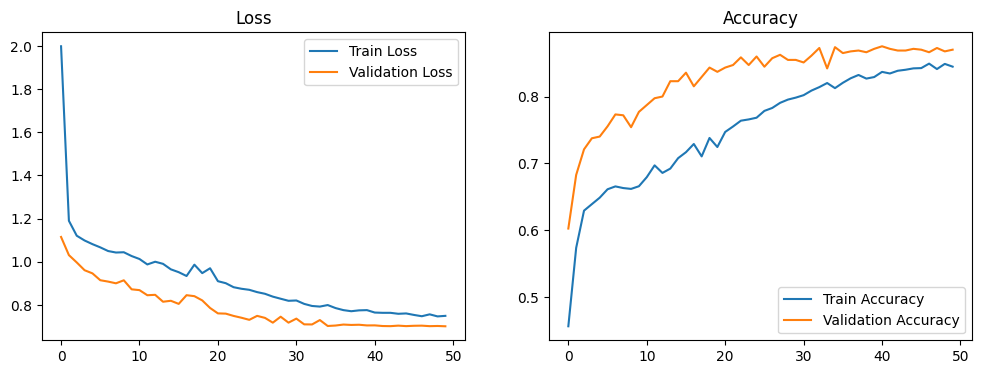

--- Training Meta Fold 2/5 ---
Original samples: 3137 -> Augmented total: 12548
Epoch 1/50 - loss: 2.3345 - acc: 0.4123 - val_loss: 1.1527 - val_acc: 0.6739
Epoch 2/50 - loss: 1.2834 - acc: 0.5004 - val_loss: 1.0537 - val_acc: 0.6994
Epoch 3/50 - loss: 1.1987 - acc: 0.5796 - val_loss: 1.0115 - val_acc: 0.7083
Epoch 4/50 - loss: 1.1414 - acc: 0.6132 - val_loss: 0.9814 - val_acc: 0.7389
Epoch 5/50 - loss: 1.1067 - acc: 0.6362 - val_loss: 0.9426 - val_acc: 0.7503
Epoch 6/50 - loss: 1.0716 - acc: 0.6534 - val_loss: 0.9228 - val_acc: 0.7618
Epoch 7/50 - loss: 1.0444 - acc: 0.6697 - val_loss: 0.9060 - val_acc: 0.7732
Epoch 8/50 - loss: 1.0427 - acc: 0.6733 - val_loss: 0.8893 - val_acc: 0.7809
Epoch 9/50 - loss: 1.0095 - acc: 0.6891 - val_loss: 0.8918 - val_acc: 0.7707
Epoch 10/50 - loss: 1.0074 - acc: 0.6960 - val_loss: 0.8721 - val_acc: 0.7987
Epoch 11/50 - loss: 0.9878 - acc: 0.7058 - val_loss: 0.8417 - val_acc: 0.7924
Epoch 12/50 - loss: 0.9673 - acc: 0.7202 - val_loss: 0.8480 - val_acc: 

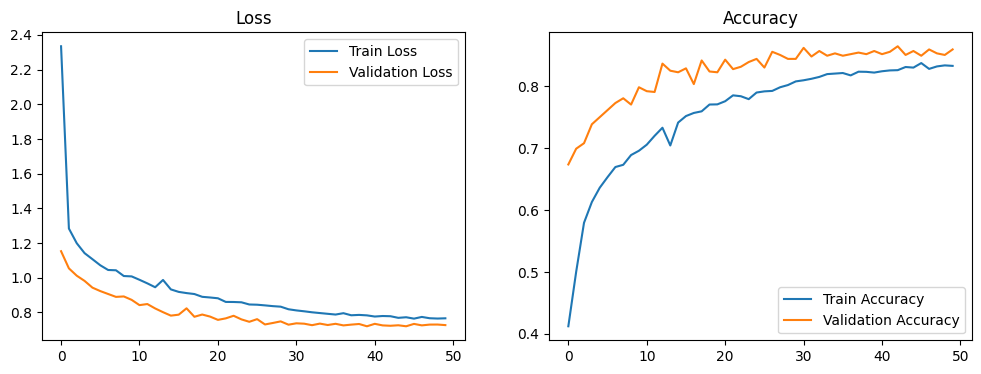

--- Training Meta Fold 3/5 ---
Original samples: 3138 -> Augmented total: 12552
Epoch 1/50 - loss: 2.5105 - acc: 0.4564 - val_loss: 1.1359 - val_acc: 0.5829
Epoch 2/50 - loss: 1.2296 - acc: 0.5605 - val_loss: 1.0476 - val_acc: 0.6798
Epoch 3/50 - loss: 1.1551 - acc: 0.6077 - val_loss: 1.0113 - val_acc: 0.6952
Epoch 4/50 - loss: 1.1141 - acc: 0.6405 - val_loss: 0.9776 - val_acc: 0.7347
Epoch 5/50 - loss: 1.0798 - acc: 0.6609 - val_loss: 0.9577 - val_acc: 0.7232
Epoch 6/50 - loss: 1.0724 - acc: 0.6607 - val_loss: 0.9557 - val_acc: 0.7270
Epoch 7/50 - loss: 1.0507 - acc: 0.6779 - val_loss: 0.9192 - val_acc: 0.7449
Epoch 8/50 - loss: 1.0260 - acc: 0.6846 - val_loss: 0.9205 - val_acc: 0.7551
Epoch 9/50 - loss: 1.0038 - acc: 0.7040 - val_loss: 0.8878 - val_acc: 0.7704
Epoch 10/50 - loss: 0.9797 - acc: 0.7146 - val_loss: 0.8826 - val_acc: 0.7819
Epoch 11/50 - loss: 0.9646 - acc: 0.7246 - val_loss: 0.8602 - val_acc: 0.7934
Epoch 12/50 - loss: 0.9546 - acc: 0.7310 - val_loss: 0.8650 - val_acc: 

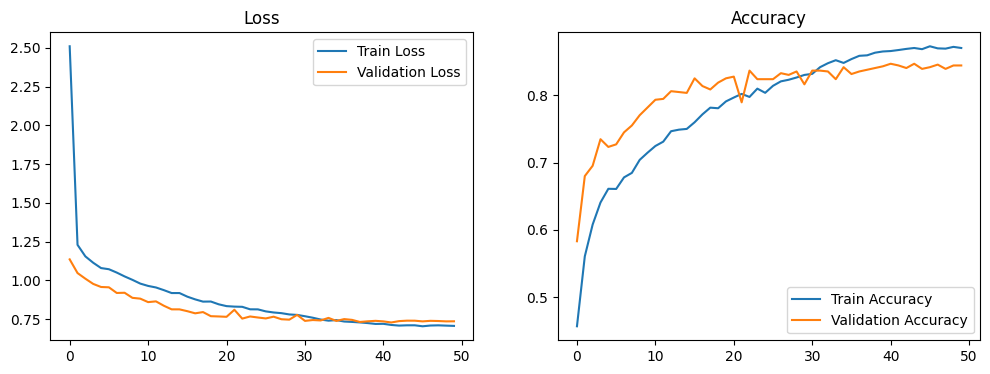

--- Training Meta Fold 4/5 ---
Original samples: 3138 -> Augmented total: 12552
Epoch 1/50 - loss: 2.3300 - acc: 0.4038 - val_loss: 1.1397 - val_acc: 0.6224
Epoch 2/50 - loss: 1.2660 - acc: 0.5326 - val_loss: 1.0699 - val_acc: 0.7054
Epoch 3/50 - loss: 1.1867 - acc: 0.5932 - val_loss: 0.9666 - val_acc: 0.7334
Epoch 4/50 - loss: 1.1257 - acc: 0.6222 - val_loss: 0.9410 - val_acc: 0.7411
Epoch 5/50 - loss: 1.0974 - acc: 0.6335 - val_loss: 0.9302 - val_acc: 0.7436
Epoch 6/50 - loss: 1.0762 - acc: 0.6397 - val_loss: 0.9199 - val_acc: 0.7487
Epoch 7/50 - loss: 1.0527 - acc: 0.6591 - val_loss: 0.8843 - val_acc: 0.7589
Epoch 8/50 - loss: 1.0253 - acc: 0.6799 - val_loss: 0.8730 - val_acc: 0.7691
Epoch 9/50 - loss: 1.0076 - acc: 0.6949 - val_loss: 0.8483 - val_acc: 0.7844
Epoch 10/50 - loss: 0.9706 - acc: 0.7157 - val_loss: 0.8649 - val_acc: 0.7730
Epoch 11/50 - loss: 0.9620 - acc: 0.7183 - val_loss: 0.8049 - val_acc: 0.8240
Epoch 12/50 - loss: 0.9456 - acc: 0.7271 - val_loss: 0.8074 - val_acc: 

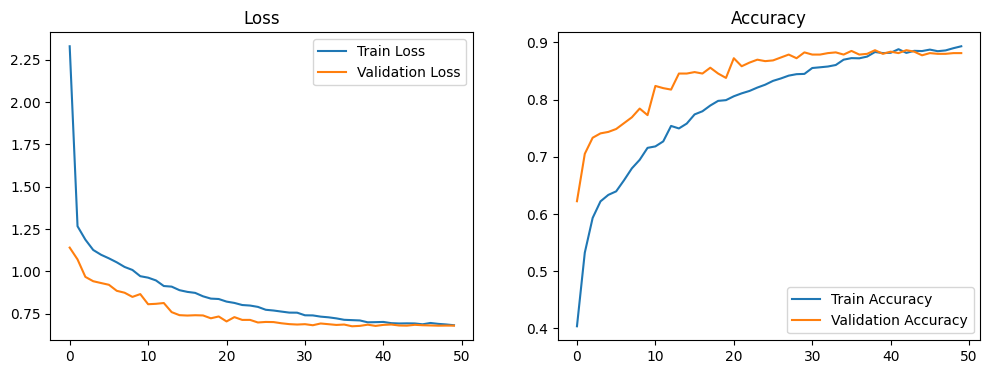

--- Training Meta Fold 5/5 ---
Original samples: 3138 -> Augmented total: 12552
Epoch 1/50 - loss: 2.0942 - acc: 0.4101 - val_loss: 1.1635 - val_acc: 0.6161
Epoch 2/50 - loss: 1.2448 - acc: 0.5515 - val_loss: 1.0278 - val_acc: 0.6990
Epoch 3/50 - loss: 1.1568 - acc: 0.6057 - val_loss: 0.9614 - val_acc: 0.7015
Epoch 4/50 - loss: 1.0907 - acc: 0.6433 - val_loss: 0.9214 - val_acc: 0.7385
Epoch 5/50 - loss: 1.0576 - acc: 0.6630 - val_loss: 0.8833 - val_acc: 0.7628
Epoch 6/50 - loss: 1.0333 - acc: 0.6781 - val_loss: 0.8760 - val_acc: 0.7691
Epoch 7/50 - loss: 1.0083 - acc: 0.6907 - val_loss: 0.8580 - val_acc: 0.7768
Epoch 8/50 - loss: 0.9908 - acc: 0.7063 - val_loss: 0.8375 - val_acc: 0.7921
Epoch 9/50 - loss: 0.9682 - acc: 0.7229 - val_loss: 0.8317 - val_acc: 0.7870
Epoch 10/50 - loss: 0.9468 - acc: 0.7327 - val_loss: 0.8338 - val_acc: 0.7806
Epoch 11/50 - loss: 0.9425 - acc: 0.7405 - val_loss: 0.8120 - val_acc: 0.8061
Epoch 12/50 - loss: 0.9283 - acc: 0.7510 - val_loss: 0.7777 - val_acc: 

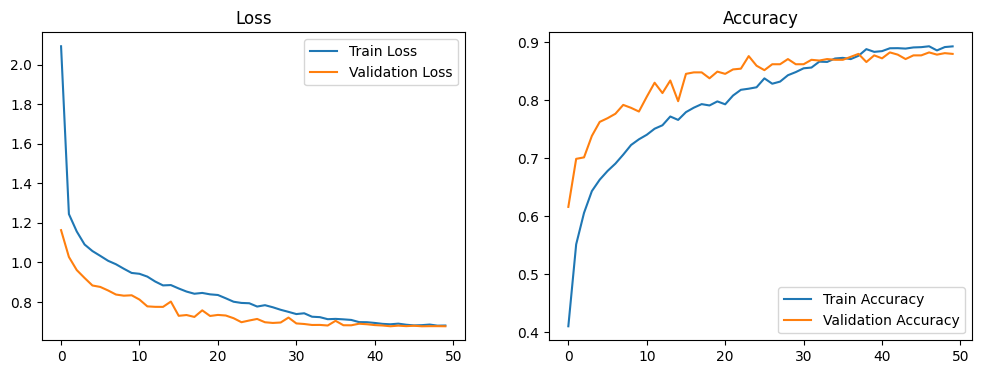

In [12]:
meta_bagging_models = []
groups = np.array(beatmap_ids)

# Initialize empty matrix for clean Out-Of-Fold CNN probability predictions
oof_cnn_predictions = np.zeros((len(X), num_classes), dtype=np.float32)

# Use GroupKFold so mapset difficulties stay grouped
gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y_numerical, groups=groups)
):
    print(f"--- Training Meta Fold {fold + 1}/5 ---")

    # Split raw unaugmented fold data
    X_fold_train, y_fold_train = X[train_idx], y_numerical[train_idx]
    X_fold_val, y_fold_val = X[val_idx], y_numerical[val_idx]
    beatmap_ids_fold_train = groups[train_idx]

    # Augment ONLY the training fold
    X_fold_train_aug, y_fold_train_aug, _ = augment_dataset(
        X_fold_train,
        y_fold_train,
        beatmap_ids_fold_train,
        augmentation_types={"horizontal", "vertical", "horizontal_vertical"},
    )

    # Convert validation fold to PyTorch Tensor (permuted to (B, C, L))
    X_fold_val = torch.as_tensor(X_fold_val, dtype=torch.float32).permute(0, 2, 1)
    y_fold_val = torch.as_tensor(y_fold_val, dtype=torch.long)

    X_fold_train_aug = X_fold_train_aug.permute(0, 2, 1)

    # Train CNN model for this fold
    model, history = train_and_evaluate(
        X_fold_train_aug,
        y_fold_train_aug,
        X_fold_val,
        y_fold_val,
        input_channels=X_fold_train_aug.shape[1],
        num_classes=num_classes,
        max_length=max_length,
        learning_rate=0.001,
        dropout_rate=0.5,  # old: 0.5
        l2_reg=0.001,
        batch_size=128,
        epochs=50,  # old: 30
        patience=15,
    )
    plot_training_history(history)
    meta_bagging_models.append(model)

    # Generate Out-of-Fold predictions for the unaugmented validation set ONLY
    model.eval()
    with torch.no_grad():
        val_inputs = X_fold_val.to(device)
        logits = model(val_inputs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    # Store clean OOF predictions in the array
    oof_cnn_predictions[val_idx] = probs

In [13]:
os.makedirs("./beatmap_classifier/models/full/bagged_models", exist_ok=True)

for i, model in enumerate(meta_bagging_models):
    torch.save(
        model.state_dict(),
        f"./beatmap_classifier/models/full/bagged_models/bagged_cnn_model_{i}.pth",
    )

np.save("./beatmap_classifier/models/full/oof_cnn_predictions.npy", oof_cnn_predictions)
np.save("./beatmap_classifier/models/full/y_numerical.npy", y_numerical.numpy())
np.save("./beatmap_classifier/models/full/beatmap_ids.npy", groups)

# XGBoost Meta Model

### Load Models and Data

In [9]:
model_kwargs = {
    "input_channels": 8,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5,
}

meta_bagging_models = load_pytorch_models(
    model_folder="./beatmap_classifier/models/full/bagged_models",
    model_class=CNNModel,
    model_kwargs=model_kwargs,
    device=device,
)

oof_cnn_predictions = np.load("./beatmap_classifier/models/full/oof_cnn_predictions.npy")
y_numerical = np.load("./beatmap_classifier/models/full/y_numerical.npy")

print(f"Loaded {len(meta_bagging_models)} CNN models")

Loaded 5 CNN models


### Check the bagging models (Out-Of-Fold)
There is no held-out test set here, so the OOF predictions (each map scored by the fold model that never saw it) are the honest estimate.

In [10]:
oof_cnn_predictions_numerical = np.argmax(oof_cnn_predictions, axis=1)

score = accuracy_score(y_numerical, oof_cnn_predictions_numerical)
cm = confusion_matrix(y_numerical, oof_cnn_predictions_numerical)
report = classification_report(
    y_numerical,
    oof_cnn_predictions_numerical,
    zero_division=0,
    target_names=["NM1", "NM2", "NM3", "NM4", "NM5"],
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"OOF Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

         NM1       0.95      0.94      0.95       895
         NM2       0.88      0.91      0.89       868
         NM3       0.83      0.87      0.85       917
         NM4       0.84      0.82      0.83       761
         NM5       0.80      0.72      0.76       481

    accuracy                           0.87      3922
   macro avg       0.86      0.85      0.85      3922
weighted avg       0.87      0.87      0.87      3922

Confusion Matrix:
 [[845   5  30  12   3]
 [  6 786  15   9  52]
 [ 21  14 798  74  10]
 [  4  13  98 626  20]
 [ 14  75  20  28 344]]
OOF Accuracy: 0.866649668536461


### Setup

Make sure that this setup matches in `/beatmap_recommender/recommender_db_setup/precompute_nm1-5.py` whenever you're done.

In [11]:
sql_feature_names = [
    "ar",
    "od",
    "circle_size",
    "star_rating",
    "bpm",
    "max_combo",
    "length_seconds",
    "object_count",
    "pp",
    "pp_aim",
    "pp_speed",
    "pp_acc",
]

movement_feature_names = [
    "slider_ratio",
    "slider_length_std",
    "speed_std",
    "speed_change_std",
    "speed_change_max",
    "angle_std",
    "angle_mean",
    "rhythm_variance",
    "distance_mean",
    "speed_change_95th",
    "angle_90th",
    "sharp_turn_ratio",
]

cnn_feature_names = [
    "CNN_NM1",
    "CNN_NM2",
    "CNN_NM3",
    "CNN_NM4",
    "CNN_NM5",
]

additional_feature_names = sql_feature_names + movement_feature_names

In [12]:
print(additional_feature_names)

['ar', 'od', 'circle_size', 'star_rating', 'bpm', 'max_combo', 'length_seconds', 'object_count', 'pp', 'pp_aim', 'pp_speed', 'pp_acc', 'slider_ratio', 'slider_length_std', 'speed_std', 'speed_change_std', 'speed_change_max', 'angle_std', 'angle_mean', 'rhythm_variance', 'distance_mean', 'speed_change_95th', 'angle_90th', 'sharp_turn_ratio']


You can add more feature groups here, if desired

In [13]:
# GROUP 1
excluded_features = {
}

group1_features = [
    feature for feature in additional_feature_names if feature not in excluded_features
]

# GROUP 2
# excluded_features = {
#     "speed_change_95th",
# }
#
# group2_features = [
#     feature
#     for feature in additional_feature_names
#     if feature not in excluded_features
# ]
#

# COMBINE ALL GROUPS TOGETHER
additional_feature_groups = {
    "group1": group1_features,
    # "group2": group2_features,
}

feature_indices = {
    group_name: [additional_feature_names.index(feature) for feature in features]
    for group_name, features in additional_feature_groups.items()
}

In [14]:
def make_xgb(params):
    return XGBClassifier(
        random_state=42,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        **params,
    )


def optimize_xgb_feature_set(
    X_additional,
    oof_cnn_predictions,
    y,
    indices,
    n_trials=50,
    seed=42,
):
    X_meta = np.hstack(
        [
            oof_cnn_predictions,
            X_additional[:, indices],
        ]
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 250, 750, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        }

        scores = []

        for train_idx, valid_idx in cv.split(X_meta, y):
            X_train = X_meta[train_idx]
            X_valid = X_meta[valid_idx]

            y_train_fold = y[train_idx]
            y_valid_fold = y[valid_idx]

            model = make_xgb(params)
            model.fit(
                X_train, y_train_fold, eval_set=[(X_valid, y_valid_fold)], verbose=False
            )
            pred = model.predict(X_valid)

            scores.append(
                f1_score(y_valid_fold, pred, average="macro", zero_division=0)
            )

        return np.mean(scores)

    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

In [15]:
def get_feature_indices(feature_names, selected_features):
    missing = [name for name in selected_features if name not in feature_names]

    if missing:
        raise ValueError(f"Features not found: {missing}")

    return [feature_names.index(name) for name in selected_features]

### (Optional) Re-tune the XGBoost Params on the Full Dataset
Skip this cell to reuse the params already tuned in `train_and_eval.ipynb`.

Change n_trials if needed.

In [16]:
studies = {}
best_params = {}

for group_name, indices in feature_indices.items():
    study = optimize_xgb_feature_set(
        X_additional=X_additional,
        oof_cnn_predictions=oof_cnn_predictions,
        y=y_numerical,
        indices=indices,
        n_trials=100,
    )

    studies[group_name] = study

    best_params[group_name] = {
        "macro_f1": study.best_value,
        "params": study.best_params,
    }

    print(f"\nBest macro F1: {study.best_value:.4f}")
    print("Best parameters:")

    for param, value in study.best_params.items():
        print(f"  {param}: {value}")

# Save this entire experiment as a new file
os.makedirs("./beatmap_classifier/models/full/xgb_params", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f"./beatmap_classifier/models/full/xgb_params/xgb_best_params_{timestamp}.json"

with open(output_path, "w") as f:
    json.dump(best_params, f, indent=4)

print(f"\nSaved best parameters to: {output_path}")

[I 2026-10-06 18:27:15,491] A new study created in memory with name: no-name-1867632a-f206-412b-b029-728970d307f0
  0%|          | 0/100 [00:02<?, ?it/s]


[W 2026-10-06 18:27:18,086] Trial 0 failed with parameters: {'n_estimators': 450, 'learning_rate': 0.0862735828664018, 'max_depth': 7, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0001707396743152812, 'reg_lambda': 5.3994844097874335} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/yoshi0428/miniconda3/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_3980048/1127348931.py", line 54, in objective
    model.fit(
    ~~~~~~~~~^
        X_train, y_train_fold, eval_set=[(X_valid, y_valid_fold)], verbose=False
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/yoshi0428/miniconda3/lib/python3.13/site-packages/xgboost/core.py", line 569, in inner_f
    return func(**kwargs)
  File "/home/yoshi0428/miniconda3/lib/python3.13/site-packa

KeyboardInterrupt: 

### Load the XGBoost Params
Defaults to the params tuned in `train_and_eval.ipynb`. Point `PARAMS_PATH` at `models/full/xgb_params/...` if you re-tuned above.

In [17]:
PARAMS_PATH = "./beatmap_classifier/models/eval/xgb_params/xgb_best_params_20261006_182441.json"

with open(PARAMS_PATH, "r") as f:
    best_params = json.load(f)

best_params

{'group1': {'macro_f1': 0.9223323964658752,
  'params': {'n_estimators': 400,
   'learning_rate': 0.04650151618518967,
   'max_depth': 2,
   'min_child_weight': 2,
   'subsample': 0.8960130383835756,
   'colsample_bytree': 0.7173216448865419,
   'reg_alpha': 0.03559577486424498,
   'reg_lambda': 0.41416527190650504}}}

### Train the Final Meta Model
Set the desired group from the JSON in `FEATURE_GROUP`.

The cross-validated score is only a sanity check; the saved meta model is fit on the full dataset.

In [18]:
FEATURE_GROUP = "group1"

params = best_params[FEATURE_GROUP]["params"]
all_features = additional_feature_groups[FEATURE_GROUP]
indices = get_feature_indices(additional_feature_names, all_features)

X_meta = np.hstack(
    [
        oof_cnn_predictions,
        X_additional[:, indices],
    ]
)

# --------------------------------------------------------------
# Cross-validated sanity check
# --------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(make_xgb(params), X_meta, y_numerical, cv=cv)

print(f"--- XGBoost Meta-Model CV Performance ---")
print(f"CV Accuracy: {accuracy_score(y_numerical, y_pred_cv) * 100:.2f}%")
print(f"CV Macro F1: {f1_score(y_numerical, y_pred_cv, average='macro'):.4f}\n")

print("Classification Report:")
print(
    classification_report(
        y_numerical, y_pred_cv, target_names=["NM1", "NM2", "NM3", "NM4", "NM5"]
    )
)
print("Confusion Matrix:")
print(confusion_matrix(y_numerical, y_pred_cv))

# --------------------------------------------------------------
# Fit on the full dataset and save
# --------------------------------------------------------------
meta_model = make_xgb(params)
meta_model.fit(X_meta, y_numerical)

with open("./beatmap_classifier/models/full/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)

--- XGBoost Meta-Model CV Performance ---
CV Accuracy: 91.97%
CV Macro F1: 0.9161

Classification Report:
              precision    recall  f1-score   support

         NM1       0.96      0.96      0.96       895
         NM2       0.92      0.93      0.92       868
         NM3       0.91      0.91      0.91       917
         NM4       0.90      0.90      0.90       761
         NM5       0.89      0.88      0.89       481

    accuracy                           0.92      3922
   macro avg       0.92      0.92      0.92      3922
weighted avg       0.92      0.92      0.92      3922

Confusion Matrix:
[[861   4  13  15   2]
 [  7 803  12  12  34]
 [ 19  11 832  46   9]
 [  4  16  48 686   7]
 [  9  37   5   5 425]]


# Analysis

In [19]:
importance = meta_model.feature_importances_
meta_model_features = cnn_feature_names + all_features

for name, value in sorted(
    zip(meta_model_features, importance), key=lambda x: x[1], reverse=True
):
    print(f"{name:30s} {value:.4f}")

CNN_NM1                        0.1578
CNN_NM2                        0.1460
CNN_NM3                        0.1312
CNN_NM4                        0.1139
CNN_NM5                        0.0834
sharp_turn_ratio               0.0761
distance_mean                  0.0502
bpm                            0.0479
angle_mean                     0.0386
slider_ratio                   0.0305
slider_length_std              0.0215
pp_speed                       0.0193
object_count                   0.0130
length_seconds                 0.0075
angle_std                      0.0072
ar                             0.0059
pp_acc                         0.0058
od                             0.0056
speed_std                      0.0055
circle_size                    0.0054
pp_aim                         0.0051
max_combo                      0.0050
star_rating                    0.0047
pp                             0.0043
angle_90th                     0.0043
rhythm_variance                0.0042
speed_change

In [20]:
feature_names = [
    "AR",
    "OD",
    "Circle Size",
    "Star Rating",
    "BPM",
    "Max Combo",
    "Length (s)",
    "Object Count",
]

print("\nRaw Additional feature ranges:")
print("-" * 70)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    print(
        f"{name:15s} "
        f"min={np.min(values):8.2f}  "
        f"max={np.max(values):8.2f}  "
        f"mean={np.mean(values):8.2f}  "
        f"median={np.median(values):8.2f}"
    )

print("\nRaw Additional feature percentiles:")
print("-" * 90)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    p = np.percentile(values, [1, 5, 25, 50, 75, 95, 99])

    print(
        f"{name:15s} "
        f"1%={p[0]:8.2f}  "
        f"5%={p[1]:8.2f}  "
        f"25%={p[2]:8.2f}  "
        f"50%={p[3]:8.2f}  "
        f"75%={p[4]:8.2f}  "
        f"95%={p[5]:8.2f}  "
        f"99%={p[6]:8.2f}"
    )


Raw Additional feature ranges:
----------------------------------------------------------------------
AR              min=    6.80  max=   10.00  mean=    9.50  median=    9.50
OD              min=    5.00  max=   10.00  mean=    8.86  median=    9.00
Circle Size     min=    2.00  max=    7.00  mean=    4.01  median=    4.00
Star Rating     min=    3.12  max=   19.09  mean=    6.79  median=    6.73
BPM             min=   50.00  max=  363.86  mean=  184.70  median=  185.00
Max Combo       min=  252.00  max=10215.00  mean= 1526.90  median= 1449.50
Length (s)      min=   18.29  max= 1645.53  mean=  192.91  median=  194.45
Object Count    min=  156.00  max= 6310.00  mean= 1086.00  median= 1022.00

Raw Additional feature percentiles:
------------------------------------------------------------------------------------------
AR              1%=    9.00  5%=    9.20  25%=    9.40  50%=    9.50  75%=    9.60  95%=    9.80  99%=   10.00
OD              1%=    7.50  5%=    8.00  25%=    8.50  50

In [21]:
bpm = raw_additional_features_array[:, 4]
for threshold in [300, 400, 500, 600, 800, 1000]:
    count = np.sum(bpm > threshold)

    print(f"bpm > {threshold:4d}: {count:6d} ({count / len(bpm) * 100:.3f}%)")

bpm >  300:     10 (0.255%)
bpm >  400:      0 (0.000%)
bpm >  500:      0 (0.000%)
bpm >  600:      0 (0.000%)
bpm >  800:      0 (0.000%)
bpm > 1000:      0 (0.000%)


In [22]:
sequence_lengths = np.array([len(seq) for seq in X])

print("Number of beatmaps:", len(sequence_lengths))
print("Min:", sequence_lengths.min())
print("Median:", np.median(sequence_lengths))
print("Mean:", sequence_lengths.mean())
print("75th:", np.percentile(sequence_lengths, 75))
print("90th:", np.percentile(sequence_lengths, 90))
print("95th:", np.percentile(sequence_lengths, 95))
print("99th:", np.percentile(sequence_lengths, 99))
print("Max:", sequence_lengths.max())

Number of beatmaps: 3922
Min: 4096
Median: 4096.0
Mean: 4096.0
75th: 4096.0
90th: 4096.0
95th: 4096.0
99th: 4096.0
Max: 4096
